In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from imblearn.over_sampling import SMOTE
import optuna
import matplotlib.pyplot as plt
import joblib

In [2]:
# Load the dataset
df = pd.read_csv(r'C:\Users\khiew\Downloads\FYP Augmented (Secondly) Dataset.csv')

In [3]:
# Drop diseases with less than 1000 instances
disease_counts = df['diseases'].value_counts()
valid_diseases = disease_counts[disease_counts >= 1000].index
df = df[df['diseases'].isin(valid_diseases)]

# Assuming that the target variable is 'diseases' and all other variables are input features
X = df.drop('diseases', axis=1)
y = df['diseases']

# Encode the target variable (diseases) if it's a categorical variable
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42)
num_classes = len(np.unique(y_train))
input_dim = X_train.shape[1]
print("Number of remaining classes in training set:", len(np.unique(y_train)))
print("Number of rows left:", len(df))

Number of remaining classes in training set: 37
Number of rows left: 44748


In [4]:
# Apply SMOTE for class balancing in the training set
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

# Print the new class distribution after SMOTE
print("Class distribution after SMOTE:")
print(pd.Series(y_train_resampled).value_counts())
print("Number of remaining classes in training set:", len(np.unique(y_train_resampled)))
# Print the number of rows in the resampled training set
print("Number of rows in the resampled training set:", len(X_train_resampled))

Class distribution after SMOTE:
22    1005
27    1005
28    1005
34    1005
6     1005
24    1005
35    1005
12    1005
0     1005
19    1005
18    1005
30    1005
13    1005
5     1005
32    1005
23    1005
16    1005
10    1005
21    1005
33    1005
1     1005
29    1005
4     1005
20    1005
7     1005
31    1005
2     1005
36    1005
8     1005
15    1005
26    1005
9     1005
3     1005
17    1005
25    1005
11    1005
14    1005
Name: count, dtype: int64
Number of remaining classes in training set: 37
Number of rows in the resampled training set: 37185


In [5]:
# Optuna objective function
def objective(trial):
    model = keras.Sequential()
    model.add(layers.Input(shape=(input_dim,)))

    # Suggest hyperparameters
    n_layers = trial.suggest_int('n_layers', 1, 3)
    for i in range(n_layers):
        num_units = trial.suggest_int(f'n_units_{i}', 64, 256, step=64)
        activation = trial.suggest_categorical(f'activation_{i}', ['relu', 'tanh'])
        model.add(layers.Dense(num_units, activation=activation))
        dropout_rate = trial.suggest_float(f'dropout_rate_{i}', 0.2, 0.5)
        model.add(layers.Dropout(dropout_rate))

    model.add(layers.Dense(num_classes, activation='softmax'))

    learning_rate = trial.suggest_float('learning_rate', 1e-4, 1e-2, log=True)
    optimizer = keras.optimizers.Adam(learning_rate=learning_rate)

    model.compile(optimizer=optimizer,
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])

    history = model.fit(X_train_resampled, y_train_resampled,
                        validation_split=0.2,
                        epochs=10,
                        batch_size=trial.suggest_categorical('batch_size', [32, 64, 128]),
                        verbose=0)

    val_accuracy = max(history.history['val_accuracy'])
    return val_accuracy

In [9]:
# Create Optuna study for optimization with persistent storage
study = optuna.create_study(
    direction='maximize',  # Assuming you are maximizing accuracy
    study_name="DNN_diseases_symptoms_dropextremelymore1000withSMOTE_secondaugmented_study", 
    storage=r"sqlite:///C:/Users/khiew/Downloads/dnn.db", 
    load_if_exists=True  # Load the study if it already exists, to resume from the last trial
)

# Optimize the study with your objective function, you can adjust the n_trials as needed
study.optimize(objective, n_trials=20)
# Print the best trial and hyperparameters
print("\nBest Trial:")
print(study.best_trial)
print("Best Hyperparameters:")
print(study.best_trial.params)

[I 2025-04-24 21:08:19,286] A new study created in RDB with name: DNN_diseases_symptoms_dropextremelymore1000withSMOTE_secondaugmented_study


[I 2025-04-24 21:08:27,664] Trial 0 finished with value: 0.844560980796814 and parameters: {'n_layers': 2, 'n_units_0': 192, 'activation_0': 'relu', 'dropout_rate_0': 0.36471859597588696, 'n_units_1': 128, 'activation_1': 'relu', 'dropout_rate_1': 0.30155239073813145, 'learning_rate': 0.00032952102061713315, 'batch_size': 64}. Best is trial 0 with value: 0.844560980796814.
[I 2025-04-24 21:08:34,868] Trial 1 finished with value: 0.8461745381355286 and parameters: {'n_layers': 3, 'n_units_0': 256, 'activation_0': 'relu', 'dropout_rate_0': 0.25926412678128813, 'n_units_1': 256, 'activation_1': 'relu', 'dropout_rate_1': 0.47799253179598294, 'n_units_2': 192, 'activation_2': 'relu', 'dropout_rate_2': 0.4663630149769032, 'learning_rate': 0.005460964743213595, 'batch_size': 128}. Best is trial 1 with value: 0.8461745381355286.
[I 2025-04-24 21:08:39,813] Trial 2 finished with value: 0.838779091835022 and parameters: {'n_layers': 3, 'n_units_0': 64, 'activation_0': 'tanh', 'dropout_rate_0': 0


Best Trial:
FrozenTrial(number=9, state=TrialState.COMPLETE, values=[0.8484603762626648], datetime_start=datetime.datetime(2025, 4, 24, 21, 9, 27, 274215), datetime_complete=datetime.datetime(2025, 4, 24, 21, 9, 44, 16423), params={'n_layers': 3, 'n_units_0': 128, 'activation_0': 'relu', 'dropout_rate_0': 0.4515251273425745, 'n_units_1': 192, 'activation_1': 'relu', 'dropout_rate_1': 0.28680395671806236, 'n_units_2': 256, 'activation_2': 'relu', 'dropout_rate_2': 0.46604592612760853, 'learning_rate': 0.0006518274920935669, 'batch_size': 32}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={'n_layers': IntDistribution(high=3, log=False, low=1, step=1), 'n_units_0': IntDistribution(high=256, log=False, low=64, step=64), 'activation_0': CategoricalDistribution(choices=('relu', 'tanh')), 'dropout_rate_0': FloatDistribution(high=0.5, log=False, low=0.2, step=None), 'n_units_1': IntDistribution(high=256, log=False, low=64, step=64), 'activation_1': CategoricalDistribut

Epoch 1/20
930/930 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.3923 - loss: 2.2079 - val_accuracy: 0.8306 - val_loss: 0.4052
Epoch 2/20
930/930 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.7688 - loss: 0.6340 - val_accuracy: 0.8413 - val_loss: 0.3609
Epoch 3/20
930/930 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8022 - loss: 0.5304 - val_accuracy: 0.8354 - val_loss: 0.3593
Epoch 4/20
930/930 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8156 - loss: 0.4861 - val_accuracy: 0.8386 - val_loss: 0.3577
Epoch 5/20
930/930 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8273 - loss: 0.4482 - val_accuracy: 0.8486 - val_loss: 0.3503
Epoch 6/20
930/930 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.8301 - loss: 0.4318 - val_accuracy: 0.8470 - val_loss: 0.3486
Epoch 7/20
930/930 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8319 - loss: 0.4244 - val_accuracy: 0.8382 - val_loss: 0.3554
Epoch 8/20
930/930 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8334 - loss: 0.4207 - val_accuracy: 0.

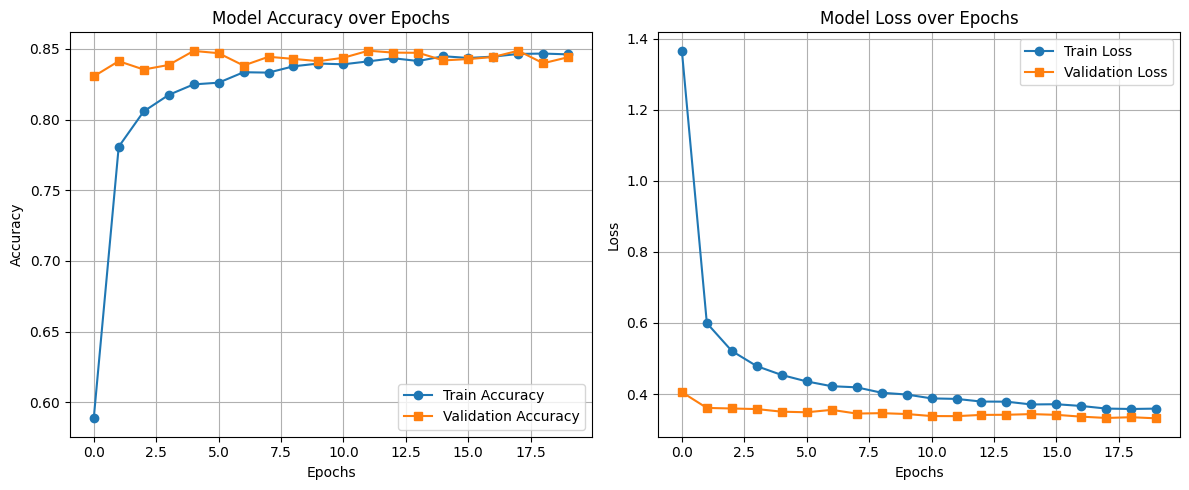

In [6]:
# Load Optuna study
study = optuna.load_study(
    study_name="DNN_diseases_symptoms_dropextremelymore1000withSMOTE_secondaugmented_study",
    storage="sqlite:///C:/Users/khiew/Downloads/dnn.db"
)

# Get best parameters
best_params = study.best_trial.params

# Rebuild model using best parameters
best_model = keras.Sequential()
best_model.add(layers.Input(shape=(input_dim,)))

for i in range(best_params['n_layers']):
    best_model.add(layers.Dense(best_params[f'n_units_{i}'], activation=best_params[f'activation_{i}']))
    best_model.add(layers.Dropout(best_params[f'dropout_rate_{i}']))

best_model.add(layers.Dense(num_classes, activation='softmax'))

best_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=best_params['learning_rate']),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Fit the model and save training history
history = best_model.fit(
    X_train_resampled,
    y_train_resampled,
    epochs=20,
    batch_size=best_params['batch_size'],
    validation_split=0.2,
    verbose=1
)

# ===========================
# Plotting Training Lifecycle
# ===========================

plt.figure(figsize=(12, 5))

# Plot Accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy', marker='o')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', marker='s')
plt.title('Model Accuracy over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

# Plot Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss', marker='o')
plt.plot(history.history['val_loss'], label='Validation Loss', marker='s')
plt.title('Model Loss over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [14]:
from sklearn.metrics import classification_report

y_pred_test = np.argmax(best_model.predict(X_test), axis=1)
print("Classification Report on Test Set:")
print(classification_report(y_test, y_pred_test, target_names=label_encoder.classes_))


280/280 [==============================] - 0s 848us/step
Classification Report on Test Set:
                                    precision    recall  f1-score   support

               acute bronchiolitis       0.76      0.97      0.85       247
                  acute bronchitis       0.72      0.83      0.77       249
                acute pancreatitis       1.00      0.74      0.85       257
                           anxiety       0.99      0.98      0.99       237
              arthritis of the hip       0.94      0.96      0.95       236
benign prostatic hyperplasia (bph)       0.69      1.00      0.82       238
                          bursitis       0.96      0.81      0.88       244
                     cholecystitis       0.72      0.95      0.82       233
    complex regional pain syndrome       0.89      0.82      0.85       258
                        concussion       1.00      0.97      0.98       217
     conjunctivitis due to allergy       0.93      0.96      0.94      

c:\Users\khiew\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\khiew\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\khiew\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, mo

In [7]:
# Save the best model to .h5 file
best_model.save(r'C:\Users\khiew\Downloads\best_dnn_model.h5')
joblib.dump(label_encoder, r'C:\Users\khiew\Downloads\label_encoder.pkl')
print("Best model saved successfully as best_dnn_model.h5")

Best model saved successfully as best_dnn_model.h5
